In [1]:
# ==========================================
# Import Libraries
# ==========================================

import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [2]:
# ==========================================
# Mount Google Drive
# ==========================================

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# ==========================================
# Load Dataset
# ==========================================

data_path = "/content/drive/MyDrive/Dataset/cardiovascular_risk_dataset.csv"

df = pd.read_csv(data_path)

df.head()

,Patient_ID,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,smoking_status,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,family_history_heart_disease,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score,risk_category
0,1,62,25.0,142,93,247,72,Never,11565,3,5.6,8.2,No,7,0.7,28.1,Medium
1,2,54,29.7,158,101,254,74,Current,4036,8,0.5,6.7,No,5,4.5,63.0,High
2,3,46,36.2,170,113,276,80,Current,3043,9,0.4,4.0,No,1,20.8,73.1,High
3,4,48,30.4,153,98,230,73,Former,5604,5,0.6,8.0,No,4,8.5,39.5,Medium
4,5,46,25.3,139,87,206,69,Current,7464,1,2.0,6.1,No,5,3.6,29.3,Medium


In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (5500, 17)


In [5]:
# ==========================================
# Inspect Dataset Columns
# ==========================================

print("Dataset Columns:\n")
print(df.columns)

Dataset Columns:

Index(['Patient_ID', 'age', 'bmi', 'systolic_bp', 'diastolic_bp',
       'cholesterol_mg_dl', 'resting_heart_rate', 'smoking_status',
       'daily_steps', 'stress_level', 'physical_activity_hours_per_week',
       'sleep_hours', 'family_history_heart_disease', 'diet_quality_score',
       'alcohol_units_per_week', 'heart_disease_risk_score', 'risk_category'],
      dtype='object')


In [6]:
# ==========================================
# Check Feature Data Types
# ==========================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Patient_ID                        5500 non-null   int64  
 1   age                               5500 non-null   int64  
 2   bmi                               5500 non-null   float64
 3   systolic_bp                       5500 non-null   int64  
 4   diastolic_bp                      5500 non-null   int64  
 5   cholesterol_mg_dl                 5500 non-null   int64  
 6   resting_heart_rate                5500 non-null   int64  
 7   smoking_status                    5500 non-null   object 
 8   daily_steps                       5500 non-null   int64  
 9   stress_level                      5500 non-null   int64  
 10  physical_activity_hours_per_week  5500 non-null   float64
 11  sleep_hours                       5500 non-null   float64
 12  family

In [7]:
# ==========================================
# Check Target Classes
# ==========================================

print(df["risk_category"].value_counts())

risk_category
Medium    2244
Low       1838
High      1418
Name: count, dtype: int64



### From your earlier research notebook, we know:

**Remove 1** - Patient_ID

**Reason:**
Just an identifier
No predictive value

**Remove 2** — heart_disease_risk_score

**Reason:**
Data leakage
This score was used to generate the target variable

In [8]:
# ==========================================
# Remove Unnecessary Columns
# ==========================================

columns_to_remove = [
    "Patient_ID",
    "heart_disease_risk_score"
]

for col in columns_to_remove:
    if col in df.columns:
        df = df.drop(columns=[col])

print("Remaining Columns:\n")
print(df.columns)

Remaining Columns:

Index(['age', 'bmi', 'systolic_bp', 'diastolic_bp', 'cholesterol_mg_dl',
       'resting_heart_rate', 'smoking_status', 'daily_steps', 'stress_level',
       'physical_activity_hours_per_week', 'sleep_hours',
       'family_history_heart_disease', 'diet_quality_score',
       'alcohol_units_per_week', 'risk_category'],
      dtype='object')


## Features Used in Deployment Model

- Age  
- BMI  
- Systolic Blood Pressure  
- Cholesterol (mg/dL)  
- Smoking Status  
- Family History of Heart Disease  
- Physical Activity (hours per week)  
- Stress Level

**Target variable:** risk_category

In [9]:
# ==========================================
# Define Features and Target
# ==========================================

features = [
    "age",
    "bmi",
    "systolic_bp",
    "cholesterol_mg_dl",
    "smoking_status",
    "family_history_heart_disease",
    "physical_activity_hours_per_week",
    "stress_level"
]

X = df[features]

y = df["risk_category"]

In [10]:
print("Selected Features:")
print(X.head())

Selected Features:
   age   bmi  systolic_bp  cholesterol_mg_dl smoking_status  \
0   62  25.0          142                247          Never   
1   54  29.7          158                254        Current   
2   46  36.2          170                276        Current   
3   48  30.4          153                230         Former   
4   46  25.3          139                206        Current   

  family_history_heart_disease  physical_activity_hours_per_week  stress_level  
0                           No                               5.6             3  
1                           No                               0.5             8  
2                           No                               0.4             9  
3                           No                               0.6             5  
4                           No                               2.0             1  


In [11]:
# ==========================================
# Encode Categorical Variables
# ==========================================

X["smoking_status"] = X["smoking_status"].map({
    "Never": 0,
    "Former": 1,
    "Current": 2
})

X["family_history_heart_disease"] = X["family_history_heart_disease"].map({
    "No": 0,
    "Yes": 1
})

/tmp/ipykernel_13397/724632162.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["smoking_status"] = X["smoking_status"].map({
/tmp/ipykernel_13397/724632162.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["family_history_heart_disease"] = X["family_history_heart_disease"].map({


In [12]:
# ==========================================
# Encode Target Variable
# ==========================================

y = y.map({
    "Low": 0,
    "Medium": 1,
    "High": 2
})

In [13]:
print("Encoded Feature Sample:\n")
print(X.head())

print("\nTarget Distribution:\n")
print(y.value_counts())

Encoded Feature Sample:

   age   bmi  systolic_bp  cholesterol_mg_dl  smoking_status  \
0   62  25.0          142                247               0   
1   54  29.7          158                254               2   
2   46  36.2          170                276               2   
3   48  30.4          153                230               1   
4   46  25.3          139                206               2   

   family_history_heart_disease  physical_activity_hours_per_week  \
0                             0                               5.6   
1                             0                               0.5   
2                             0                               0.4   
3                             0                               0.6   
4                             0                               2.0   

   stress_level  
0             3  
1             8  
2             9  
3             5  
4             1  

Target Distribution:

risk_category
1    2244
0    1838
2    1418


In [14]:
from sklearn.model_selection import train_test_split

# ==========================================
# Train-Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (4400, 8)
Testing samples: (1100, 8)


In [15]:
from sklearn.preprocessing import StandardScaler

# ==========================================
# Feature Scaling
# ==========================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
from sklearn.linear_model import LogisticRegression

# ==========================================
# Train Logistic Regression Model
# ==========================================

model = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=1000
)

model.fit(X_train_scaled, y_train)

print("Model training complete")

Model training complete


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [20]:
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Model predictions
y_pred = model.predict(X_test_scaled)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", round(accuracy * 100, 2), "%\n")

# Convert classification report to table
report = classification_report(y_test, y_pred, output_dict=True)

report_df = pd.DataFrame(report).transpose()

# Round values for clean display
report_df = report_df.round(3)

print("Classification Report Table:\n")
print(report_df)

Model Accuracy: 93.09 %

Classification Report Table:

              precision  recall  f1-score   support
0                 0.942   0.928     0.935   348.000
1                 0.915   0.922     0.918   464.000
2                 0.945   0.948     0.946   288.000
accuracy          0.931   0.931     0.931     0.931
macro avg         0.934   0.933     0.933  1100.000
weighted avg      0.931   0.931     0.931  1100.000


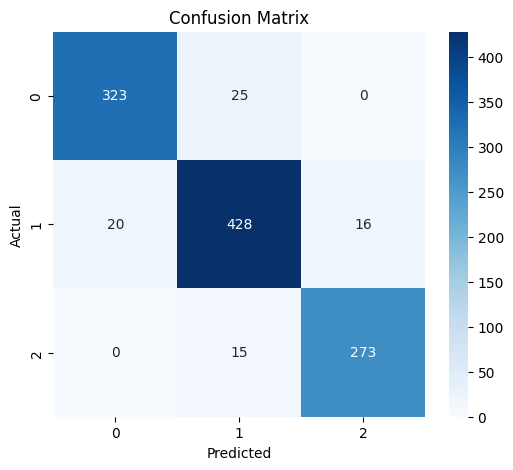

In [21]:
# ==========================================
# Confusion Matrix
# ==========================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [22]:
!pip install shap

In [23]:
import shap

In [24]:
# ==========================================
# Feature Label Mapping
# ==========================================

feature_labels = {
    "age": "Age",
    "bmi": "Body Mass Index (BMI)",
    "systolic_bp": "Systolic Blood Pressure",
    "cholesterol_mg_dl": "Cholesterol Level",
    "smoking_status": "Smoking Habit",
    "family_history_heart_disease": "Family History of Heart Disease",
    "physical_activity_hours_per_week": "Physical Activity Level",
    "stress_level": "Stress Level"
}

In [25]:
health_rules = {
    "age": {"young": 30, "old": 60},
    "bmi": {"normal_low": 18.5, "normal_high": 24.9},
    "systolic_bp": {"normal": 120, "high": 140},
    "cholesterol_mg_dl": {"normal": 200},
    "stress_level": {"moderate": 5, "high": 8},
    "physical_activity_hours_per_week": {"active": 3}
}

In [26]:
def analyze_health(sample):

    analysis = []
    protective = []

    age = sample["age"].values[0]
    bmi = sample["bmi"].values[0]
    bp = sample["systolic_bp"].values[0]
    chol = sample["cholesterol_mg_dl"].values[0]
    stress = sample["stress_level"].values[0]
    activity = sample["physical_activity_hours_per_week"].values[0]

    if age > health_rules["age"]["old"]:
        analysis.append("Advanced age is associated with increased cardiovascular risk")

    if bmi > health_rules["bmi"]["normal_high"]:
        analysis.append("Body Mass Index indicates overweight condition")
    elif bmi < health_rules["bmi"]["normal_high"]:
        protective.append("BMI appears within a healthy range")

    if bp > health_rules["systolic_bp"]["high"]:
        analysis.append("Systolic blood pressure is higher than recommended")

    if chol > health_rules["cholesterol_mg_dl"]["normal"]:
        analysis.append("Cholesterol level is above the optimal range")

    if stress >= health_rules["stress_level"]["high"]:
        analysis.append("High stress levels may contribute to cardiovascular risk")

    if activity >= health_rules["physical_activity_hours_per_week"]["active"]:
        protective.append("Regular physical activity helps reduce cardiovascular risk")

    return analysis, protective

In [27]:
def shap_feature_impact(sample, shap_values, prediction_class):

    contributions = shap_values.values[0][:, prediction_class]
    feature_names = sample.columns

    feature_data = []

    for i, value in enumerate(contributions):
        feature_data.append((feature_names[i], value))

    feature_data = sorted(feature_data, key=lambda x: abs(x[1]), reverse=True)

    important = []

    for feature, value in feature_data[:4]:
        label = feature_labels.get(feature, feature)
        important.append(label)

    return important

In [28]:
def generate_full_explanation(sample, shap_values, prediction_class):

    key_factors = shap_feature_impact(sample, shap_values, prediction_class)

    analysis, protective = analyze_health(sample)

    return key_factors, analysis, protective

In [29]:
# ==========================================
# Create SHAP Explainer
# ==========================================

explainer = shap.Explainer(model, X_train_scaled)

In [30]:
# ==========================================
# Generate SHAP Explanation
# ==========================================

sample = pd.DataFrame([{
    "age":55,
    "bmi":27.5,
    "systolic_bp":145,
    "cholesterol_mg_dl":220,
    "smoking_status":2,
    "family_history_heart_disease":1,
    "physical_activity_hours_per_week":1,
    "stress_level":7
}])

sample_scaled = scaler.transform(sample)

prediction = model.predict(sample_scaled)

shap_values = explainer(sample_scaled)

print("Prediction:", prediction)

Prediction: [2]


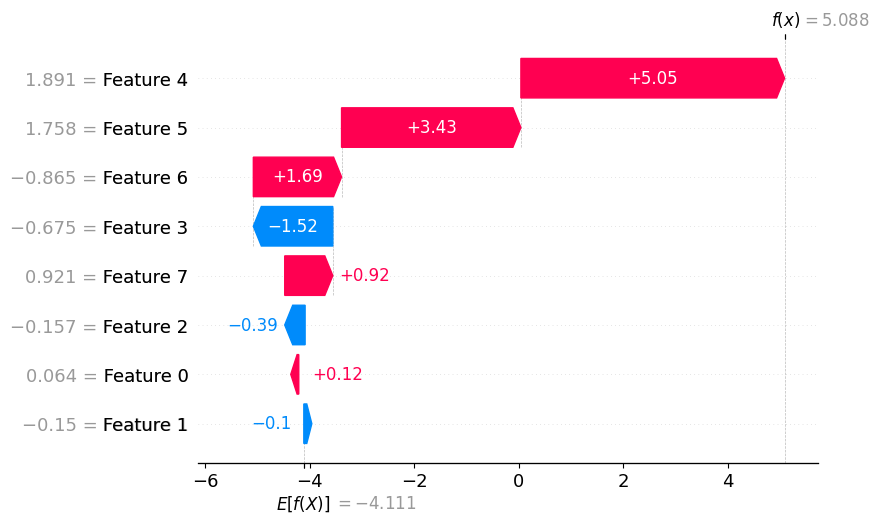

In [31]:
shap.plots.waterfall(shap_values[0, :, prediction[0]])

In [32]:
risk_labels = ["Low Risk", "Medium Risk", "High Risk"]

prediction_class = int(prediction[0])

key, analysis, protect = generate_full_explanation(
    sample,
    shap_values,
    prediction_class
)

print(f"\nPrediction: {risk_labels[prediction_class]}")

print("\nKey Contributing Factors")
print("--------------------------------")
for k in key:
    print("•", k)

print("\nHealth Analysis")
print("--------------------------------")
for a in analysis:
    print("•", a)

print("\nProtective Factors")
print("--------------------------------")
for p in protect:
    print("•", p)


Prediction: High Risk

Key Contributing Factors
--------------------------------
• Smoking Habit
• Family History of Heart Disease
• Physical Activity Level
• Cholesterol Level

Health Analysis
--------------------------------
• Body Mass Index indicates overweight condition
• Systolic blood pressure is higher than recommended
• Cholesterol level is above the optimal range

Protective Factors
--------------------------------


In [33]:
import joblib

joblib.dump(model, "heart_risk_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model saved successfully.")

Model saved successfully.


In [34]:
model_loaded = joblib.load("heart_risk_model.pkl")
scaler_loaded = joblib.load("scaler.pkl")

sample_scaled = scaler_loaded.transform(sample)

prediction_test = model_loaded.predict(sample_scaled)

print("Loaded Model Prediction:",
      ["Low Risk","Medium Risk","High Risk"][int(prediction_test[0])])

Loaded Model Prediction: High Risk


In [35]:
# ==========================================
# Verify Saved Model + Explanation
# ==========================================

model_loaded = joblib.load("heart_risk_model.pkl")
scaler_loaded = joblib.load("scaler.pkl")

sample_scaled = scaler_loaded.transform(sample)

prediction_test = model_loaded.predict(sample_scaled)

prediction_class = int(prediction_test[0])

# Recreate SHAP explainer for loaded model
explainer_loaded = shap.Explainer(model_loaded, X_train_scaled)

shap_values_loaded = explainer_loaded(sample_scaled)

# Generate explanation
key, analysis, protect = generate_full_explanation(
    sample,
    shap_values_loaded,
    prediction_class
)

risk_labels = ["Low Risk", "Medium Risk", "High Risk"]

print("\nPrediction:", risk_labels[prediction_class])

print("\nKey Contributing Factors")
print("--------------------------------")
for k in key:
    print("•", k)

print("\nHealth Analysis")
print("--------------------------------")
for a in analysis:
    print("•", a)

print("\nProtective Factors")
print("--------------------------------")
for p in protect:
    print("•", p)


Prediction: High Risk

Key Contributing Factors
--------------------------------
• Smoking Habit
• Family History of Heart Disease
• Physical Activity Level
• Cholesterol Level

Health Analysis
--------------------------------
• Body Mass Index indicates overweight condition
• Systolic blood pressure is higher than recommended
• Cholesterol level is above the optimal range

Protective Factors
--------------------------------
